In [1]:
import pickle
import functools

from notebooks.utils import (
    generate_layerwise_visualization_v2, 
    generate_layerwise_visualization_v3,
    plot_comparison_with_agreement,
    is_pair_interesting
)

In [2]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("cross-encoder/ms-marco-MiniLM-L12-v2")

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}")

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


NUM_HEADS: 12, NUM_LAYERS: 12, HIDDEN_DIM: 1536


<Figure size 640x480 with 0 Axes>

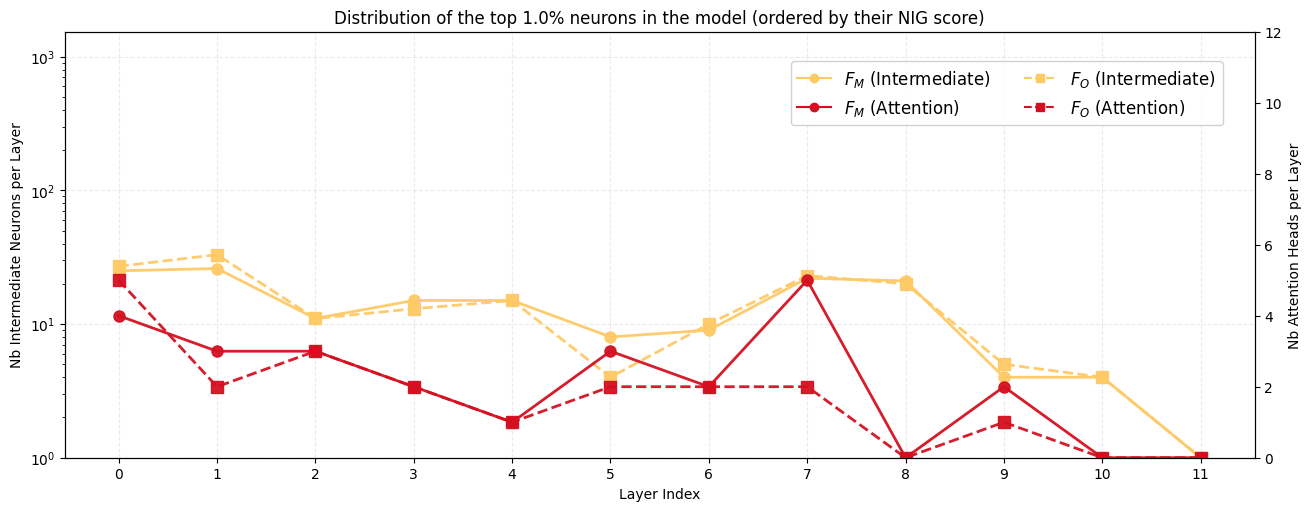

In [3]:
model = "minilm"
percentage = 0.01
names = ["msmarco_fusion", "OOD_fusion"]
paths = [
    f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/09a8805400568ac275dfdb29fdb655ec19c94489395d5c67f4c6de29947d73be/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

<Figure size 640x480 with 0 Axes>

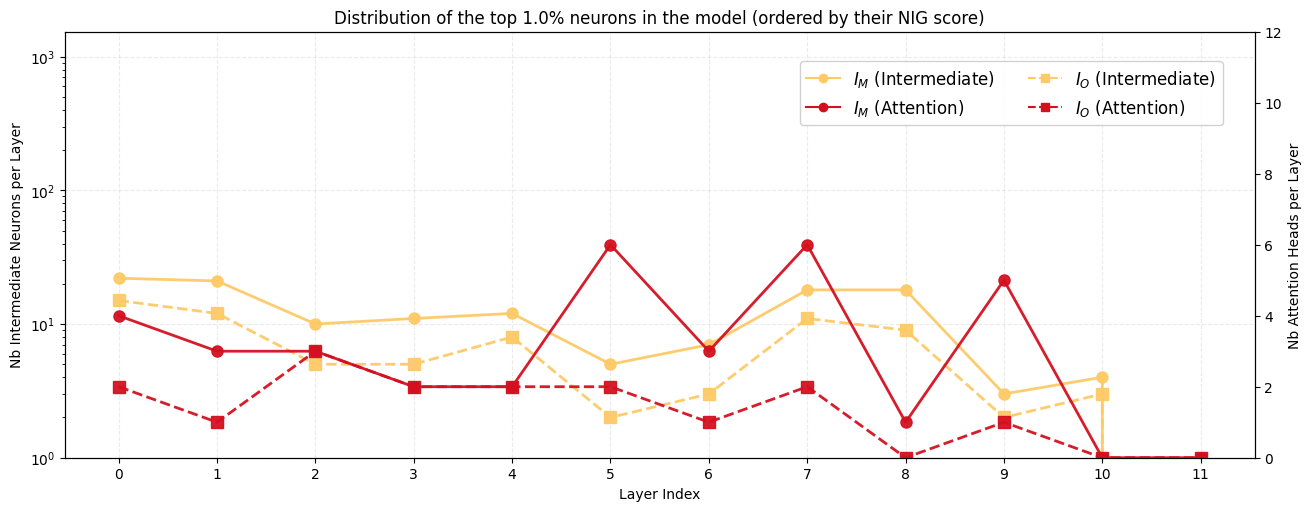

In [4]:
model = "minilm"
percentage = 0.01
names = ["msmarco_intersection", "OOD_intersection"]
paths = [
    f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/09a8805400568ac275dfdb29fdb655ec19c94489395d5c67f4c6de29947d73be/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

<Figure size 640x480 with 0 Axes>

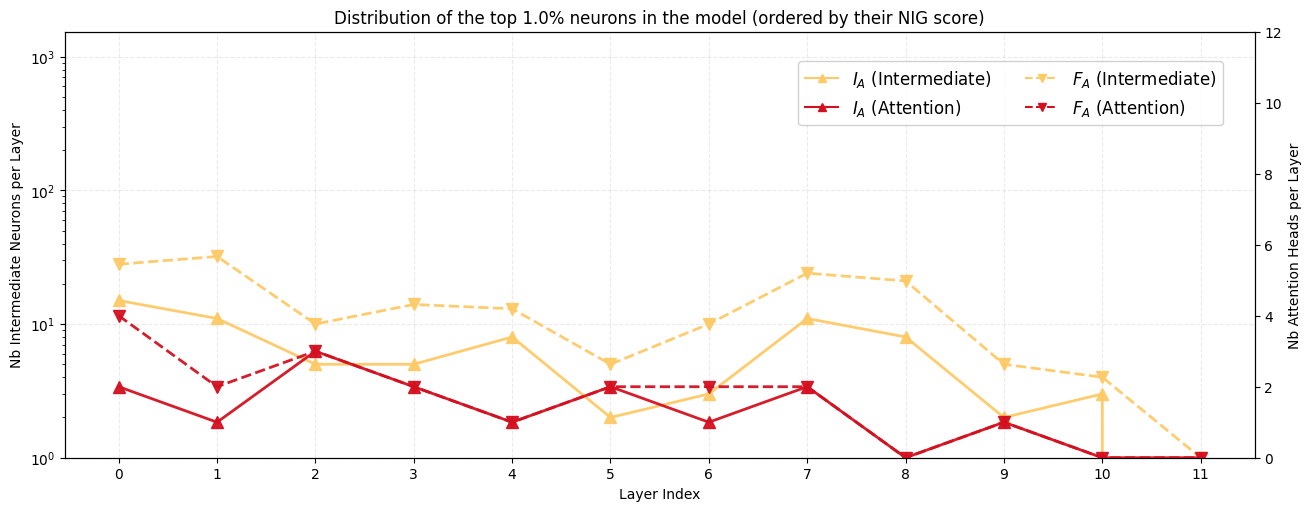

In [5]:
model = "minilm"
percentage = 0.01
names = ["ALL_intersection", "ALL_fusion"]
paths = [
    f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/09a8805400568ac275dfdb29fdb655ec19c94489395d5c67f4c6de29947d73be/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

/home/vast/CE-relevance-integration/src/notebooks/utils.py:457: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(bottom=0, top=100)


<Figure size 640x480 with 0 Axes>

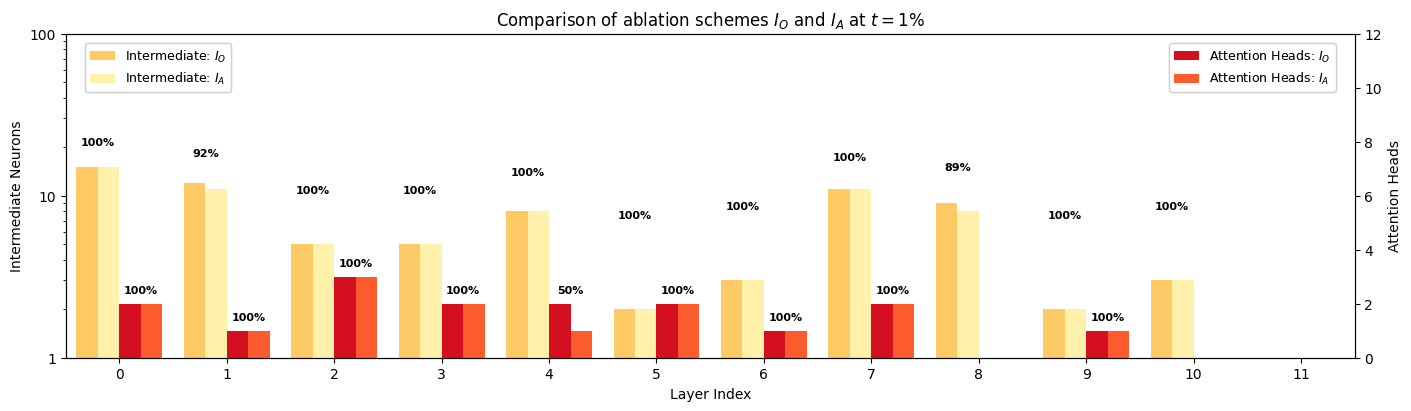

In [9]:
percentage = 0.01    
path1 = f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/09a8805400568ac275dfdb29fdb655ec19c94489395d5c67f4c6de29947d73be/ablation_schemes_at_percentage{percentage}_OOD_intersection.pkl"
path2 = f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/09a8805400568ac275dfdb29fdb655ec19c94489395d5c67f4c6de29947d73be/ablation_schemes_at_percentage{percentage}_ALL_intersection.pkl"
model_name = "minilm"

with open(path1, "rb") as f1, open(path2, "rb") as f2:
    raw1 = pickle.load(f1)
    raw2 = pickle.load(f2)

plot_comparison_with_agreement(
    raw1, raw2,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    model_name=model_name
)

In [10]:
target_modules_regex = ["attention_probs"]

nig_pkl_files = [
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/239aa56729eb761594147e124a9d85d9cc46e39c81f514d005a1f5677698a772/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/80c98ad56fdd4174c585d4d83fc6fdda1a1b88b36241c931371617532070a9d0/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/1ec409d032d7b259e25c0519d0e0fca80fe501af0df0a91f8e233eaf6714409d/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/546839f970466a3ed760fa7f5c48c1e18db183bfad2e6ac177c2d86c01e6dce0/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/909949ccf9f5d2dea4e02c70575b965df550d2f93f59ae0b32979f2b70a4bdfa/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/43de12a8e53ebe9a4e1782bc3f67c46d6eacc5586442169735457631c71310aa/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/6aef2d9d3405a072650412c6cb505cf73e832c94cb5f9063f3c1b5d1fe196e6f/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/8de379020906d4f297879852ccf267e45d05644e9a4354ff94da549b3a551e5f/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/512f196a9a955260437bf682fad6416dd90f582c8fed5bff7faa0462ccb34f78/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/338040cf65ec5abd6e7216c340d2287b91b2d34ce8d4c5bcf8c38c6b969220d2/aggregation_result.pkl"
]
target_fusion_dict = dict()
for idx, nig_pkl_file in enumerate(nig_pkl_files):
    with open(nig_pkl_file, 'rb') as f:
        nig_model = pickle.load(f)

    nig_model = dict(filter(functools.partial(is_pair_interesting, regex=target_modules_regex), nig_model.items()))

    attention_probs_keys = [key for key in nig_model.keys() if "attention_probs" in key]
    # As the attention_probs module is a 4D tensors with an additional dimensio for the attention_heads
    # we split it into attention_heads 3D tensors in order for it to match the shape of the others
    for key in attention_probs_keys:
        if "attention_probs" in key:
            attention_probs = nig_model.pop(key)
            for direction, values in attention_probs.items():
                for n, attention_head in enumerate(values):
                    if key + f'.{n}' in nig_model.keys():
                        nig_model[key + f'.{n}'][direction] = attention_head # Little trick to tranform every tensor to the same shape
                    else:
                        nig_model[key + f'.{n}'] = {direction: attention_head}

    if idx == 0:
        for module, values_per_input_type in nig_model.items():
            target_fusion_dict[module] = dict()
            for input_type, value in values_per_input_type.items():
                target_fusion_dict[module][input_type] = value

    else:
        for module, values_per_input_type in nig_model.items():
            for input_type, value in values_per_input_type.items():
                target_fusion_dict[module][input_type] += value

for module, value_per_input_type in target_fusion_dict.items():
    for input_type, value in value_per_input_type.items():
        target_fusion_dict[module][input_type] = value / len(nig_pkl_files)

sorted_target_fusion_dict = dict(
    sorted(
        target_fusion_dict.items(),
        key=lambda item: item[1]['all'],
        reverse=True
    )
)

print(sorted_target_fusion_dict.keys())
parsed_keys_dict = {
    f"{k.split('.')[3]}/{k.split('.')[-1]}": v
    for k, v in sorted_target_fusion_dict.items()
}
print(list(parsed_keys_dict.keys())[0:10])

dict_keys(['bert.encoder.layer.4.attention.self.attention_probs.9', 'bert.encoder.layer.1.attention.self.attention_probs.7', 'bert.encoder.layer.2.attention.self.attention_probs.1', 'bert.encoder.layer.5.attention.self.attention_probs.7', 'bert.encoder.layer.7.attention.self.attention_probs.9', 'bert.encoder.layer.6.attention.self.attention_probs.5', 'bert.encoder.layer.5.attention.self.attention_probs.9', 'bert.encoder.layer.3.attention.self.attention_probs.1', 'bert.encoder.layer.2.attention.self.attention_probs.10', 'bert.encoder.layer.7.attention.self.attention_probs.1', 'bert.encoder.layer.3.attention.self.attention_probs.8', 'bert.encoder.layer.0.attention.self.attention_probs.5', 'bert.encoder.layer.2.attention.self.attention_probs.5', 'bert.encoder.layer.6.attention.self.attention_probs.3', 'bert.encoder.layer.0.attention.self.attention_probs.1', 'bert.encoder.layer.9.attention.self.attention_probs.8', 'bert.encoder.layer.1.attention.self.attention_probs.4', 'bert.encoder.layer